# Graduation Lab (Week 6)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score


In [3]:
college = pd.read_csv('/workspaces/DS-3021/data/cc_institution_details.csv')
college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


### 1. Use the question/target variable you submitted from last week and build a model to answer the question you created for this dataset. 

Question: Can we predict the type of college based on number of awards per 100 students, hbcu status, cohort size, percentage of full time students, and the number of colleges in the same state and sector?

In [4]:
#Target: control
#independents: awards_per_value, hbcu, state_sector_ct, cohort_size, ft_pct
columns_used = ['control','hbcu', 'cohort_size', 'awards_per_value', 'state_sector_ct', 'ft_pct']
college_filtered = college[columns_used]

In [5]:
def college_cleaning(dataset):
    global Train, Test, Tune
    #clean up hbcu column
    dataset['hbcu'].fillna('N', inplace=True)
    dataset['hbcu'].replace('X', 'Y', inplace=True)
    dataset.dropna(inplace=True)
    #simplify control column
    dataset['control'].replace('Private not-for-profit', 'Private', inplace=True)
    dataset['control'].replace('Private for-profit', 'Private', inplace=True)
    # Convert specified columns to 'category' dtype individually
    Column_list = ['control', 'hbcu']
    for column in Column_list:
        dataset[column] = dataset[column].astype('category')
    #drop outliers
    dataset = dataset[dataset['cohort_size'] <= 8100]
    dataset = dataset[dataset['awards_per_value'] <= 77]
    #standardize the data!
    numeric_columns = ['cohort_size', 'awards_per_value', 'state_sector_ct', 'ft_pct']
    for column in numeric_columns:
        col_sc = StandardScaler().fit_transform(dataset[[column]])
        dataset[column] = col_sc
    #hot one encode the category variables!
    college_1h = pd.get_dummies(dataset, columns = ['hbcu']) 
    #partition
    random.seed(32)
    np.random.seed(32)
    Train, Test = train_test_split(college_1h,  train_size = 2475)
    Tune, Test = train_test_split(Test,  train_size = .5)
    print('Clean Train, Test, and Tune datasets produced')

In [6]:
college_cleaning(college_filtered)

Clean Train, Test, and Tune datasets produced


/tmp/ipykernel_845/4244527381.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_845/4244527381.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_845/4244527381.py:5: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [7]:
#separate features and target variable
X_train = Train.drop('control', axis=1)
Y_train = Train['control']
X_tune = Tune.drop('control', axis=1)
Y_tune = Tune['control']
X_test = Test.drop('control', axis=1)
Y_test = Test['control']

# Initialize the DecisionTreeClassifier
dtree = DecisionTreeClassifier()

# Fit the model on the training data
dtree.fit(X_train, Y_train)

# Predict on the test data
y_pred_dtree = dtree.predict(X_test)

# Calculate precision
precision = precision_score(Y_test, y_pred_dtree, average='macro')

print(f'Precision: {precision}')

Precision: 0.8606927961171504


### 2. Build a kNN model to predict your target variable using 3 nearest neighbors. Make sure it is a classification problem, meaning if needed changed the target variable.

In [8]:
random.seed(41)
np.random.seed(41)

class_knn = KNeighborsClassifier(n_neighbors=3)
class_knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

### 3. Create a dataframe that includes the test target values, test predicted values, and test probabilities of the positive class.

In [9]:
Y_preds_3 = class_knn.predict(X_test)
Y_probs_3 = class_knn.predict_proba(X_test)

table = pd.DataFrame({'Y':Y_test, 'Y_pred':Y_preds_3, 'Pos_Prob':Y_probs_3[:,0]})
table

,Y,Y_pred,Pos_Prob
147,Private,Private,1.000000
1217,Private,Private,1.000000
1251,Private,Private,0.666667
71,Private,Public,0.333333
1657,Public,Public,0.000000
...,...,...,...
1596,Public,Public,0.000000
666,Public,Public,0.000000
360,Public,Public,0.000000
2122,Public,Private,0.666667


### 4. No code question: If you adjusted the k hyperparameter what do you think would happen to the threshold function? Would the confusion look the same at the same threshold levels or not? Why or why not?

If you made k larger, the threshold function could have a bigger impact. When you look at the probas for a k value of only 3, there are only 4 options for the probability. A higher k means more possible probabilities, giving the threshold function more options that would actually change the model.

As for the confusion matrix, it would look different even if the threshold remained constant. A higher k means more neighbors are considered, which could change the predictions.

### 5. Evaluate the results using the confusion matrix. Then "walk" through your question, summarize what concerns or positive elements do you have about the model as it relates to your question? 

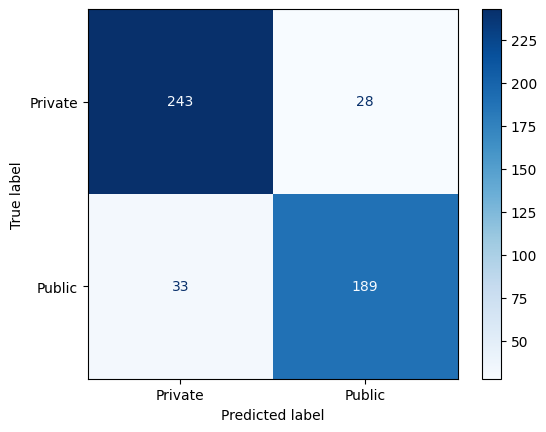

In [10]:
#making a confusion matrix with the test results
cm = confusion_matrix(Y_test, Y_preds_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_knn.classes_)
disp.plot(cmap=plt.cm.Blues)

In [11]:
sensitivity = 189/(189+33)
specificity = 243/(243+28)
print(sensitivity, specificity)

0.8513513513513513 0.8966789667896679


Our model is performing pretty well! It seems that we can predict the type of college based on number of awards per 100 students, hbcu status, cohort size, percentage of full time students, and the number of colleges in the same state and sector- with decent accuracy. The model is somewhat better at identifying private colleges as compared to public. That said, there are some false positives and false negatives to be aware of. Going forward, I would test out different k values and different thresholds to see if we can get those false predictions.

### 6. Create two functions: One that cleans the data & splits into training|test and one that allows you to train and test the model with different k and threshold values, then use them to optimize your model (test your model with several k and threshold combinations). Try not to use variable names in the functions, but if you need to that's fine. (If you can't get the k function and threshold function to work in one function just run them separately.) 

In [47]:
def clean_split(dataset):
    #clean up hbcu column
    dataset['hbcu'].fillna('N', inplace=True)
    dataset['hbcu'].replace('X', 'Y', inplace=True)
    dataset.dropna(inplace=True)
    #simplify control column
    dataset['control'].replace('Private not-for-profit', 'Private', inplace=True)
    dataset['control'].replace('Private for-profit', 'Private', inplace=True)
    # Convert specified columns to 'category' dtype individually
    Column_list = ['control', 'hbcu']
    for column in Column_list:
        dataset[column] = dataset[column].astype('category')
    #drop outliers
    dataset = dataset[dataset['cohort_size'] <= 8100]
    dataset = dataset[dataset['awards_per_value'] <= 77]
    #standardize the data!
    numeric_columns = ['cohort_size', 'awards_per_value', 'state_sector_ct', 'ft_pct']
    for column in numeric_columns:
        col_sc = StandardScaler().fit_transform(dataset[[column]])
        dataset[column] = col_sc
    #hot one encode the category variables!
    college_1h = pd.get_dummies(dataset, columns = ['hbcu']) 
    #partition
    random.seed(32)
    np.random.seed(32)
    Train, Test = train_test_split(college_1h,  train_size = 2475)
    print('Clean Train, Test, and Tune datasets produced')
    return Train, Test


In [48]:
def optimizer(xtrain, xtest, ytrain, ytest, k, thresh, pos, neg):
    random.seed(41)
    np.random.seed(41)
    #train a model
    class_knn = KNeighborsClassifier(n_neighbors=k)
    class_knn.fit(xtrain, ytrain)
    #predict on test set
    y_preds = class_knn.predict(xtest)
    y_probs = class_knn.predict_proba(xtest)[:,0]
    #adjust threshold
    thres = pd.DataFrame({'new_preds': [pos if i > thresh else neg for i in y_probs]})
    thres.new_preds = thres.new_preds.astype('category')
    #accuracy
    bal_acc = metrics.balanced_accuracy_score(ytest, thres.new_preds)
    return bal_acc

In [50]:
sets = clean_split(college_filtered)
Train = sets[0]
Test = sets[1]
#separate features and target variable
X_train = Train.drop('control', axis=1)
Y_train = Train['control']
X_test = Test.drop('control', axis=1)
Y_test = Test['control']

Clean Train, Test, and Tune datasets produced


/tmp/ipykernel_845/828264397.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_845/828264397.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_845/828264397.py:4: FutureWarning: A value is trying to be set on a copy of a DataFr

In [51]:
ks = []
thresholds = []
accuracies = []

for i in [3,5,7,9,11]:
    for j in [.1,.3,.5,.7,.9]:
        BA = optimizer(X_train, X_test, Y_train, Y_test, i, j, 'Private', 'Public')
        ks.append(i)
        thresholds.append(j)
        accuracies.append(BA)

results = pd.DataFrame({'k':ks, 'threshold':thresholds, 'balanced accuracy':accuracies})
results = results.sort_values(by='balanced accuracy', ascending=False)
results.head()
        

,k,threshold,balanced accuracy
22,11,0.5,0.893960
17,9,0.5,0.893646
12,7,0.5,0.884705
13,7,0.7,0.884505
23,11,0.7,0.879965


### 7. How well does the model perform? Did the interaction of the adjusted thresholds and k values help the model?

The best model performed quite well with a balanced accuracy of 0.905! The model works best when it considers 11 neighbors and has a threshold of 0.5. Adjusting these values definitely helped the model!

### 8. Choose another variable as the target in the dataset and create another kNN model using the two functions you created in step 6.

In [52]:
Train['control'] = pd.get_dummies(Train['control'], drop_first=True)
Test['control'] = pd.get_dummies(Test['control'], drop_first=True)
Train['hbcu_Y'] = Train['hbcu_Y'].astype('category')
Test['hbcu_Y'] = Test['hbcu_Y'].astype('category')

In [53]:
#let's try having hbcu status as the target
X_train = Train.drop(['hbcu_N', 'hbcu_Y'], axis=1)
Y_train = Train['hbcu_Y']
X_test = Test.drop(['hbcu_N', 'hbcu_Y'], axis=1)
Y_test = Test['hbcu_Y']

In [54]:
Y_test

1792    False
2418    False
1083    False
1142    False
306     False
        ...  
1847    False
1118    False
1567    False
1063    False
469     False
Name: hbcu_Y, Length: 985, dtype: category
Categories (2, bool): [False, True]

In [63]:
ks = []
thresholds = []
accuracies = []

for i in [3,5,7,9,11]:
    for j in [.1,.3,.5,.7,.9]:
        BA = optimizer(X_train, X_test, Y_train, Y_test, i, j, False, True)
        ks.append(i)
        thresholds.append(j)
        accuracies.append(BA)

results = pd.DataFrame({'k':ks, 'threshold':thresholds, 'balanced accuracy':accuracies})
results = results.sort_values(by='balanced accuracy', ascending=False)
results.head()

,k,threshold,balanced accuracy
19,9,0.9,0.877387
14,7,0.9,0.864610
9,5,0.9,0.857052
3,3,0.7,0.809847
4,3,0.9,0.809847


WHen hbcu is the target variable, my model performs best when considering 9 neighbors and with a threshold of 0.9.